# Session 19 — Linear Regression: Concept, Implementation, Prediction
### Module 5: Supervised Machine Learning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


## 1. Quick Recap

- Regression predicts a **continuous numeric value**
- We always split data into **train** and **test** sets before building a model
- Today we build our first real regression model: **Linear Regression**


## 2. The Concept Behind Linear Regression

Linear regression tries to fit a **straight line** (or, with multiple features, a flat plane/hyperplane) through the data that best predicts the target value.

For a single feature, the line has the familiar form:

**y = m×x + b**

- **y** — the predicted target value
- **x** — the input feature
- **m** — the slope (how much y changes when x increases by 1 unit) — also called a *coefficient*
- **b** — the intercept (the predicted value of y when x = 0)

With multiple features, this generalizes to:

**y = w₁x₁ + w₂x₂ + ... + wₙxₙ + b**

Each feature gets its own coefficient (weight), and the model learns all of these weights from the training data.


## 3. How Does the Model "Learn" the Best Line?

Out of all the possible lines that could be drawn, linear regression picks the one that minimizes the total prediction error across the training data.

- The **error** for a single point is the difference between the actual value and the predicted value: `error = actual - predicted`
- These errors are squared (so positive and negative errors don't cancel out) and averaged — this is called the **Mean Squared Error (MSE)**
- The model's training process finds the slope and intercept that make this MSE as small as possible

This is why linear regression is sometimes called "least squares" regression — it minimizes the sum of squared errors.


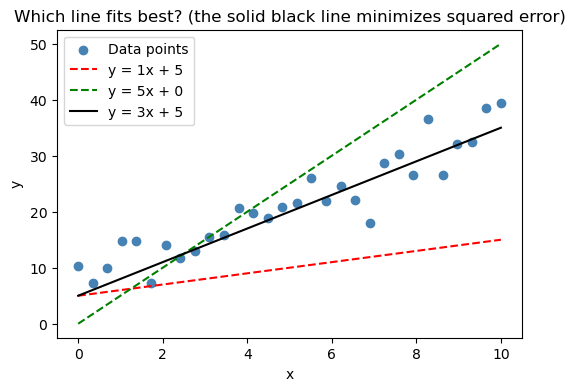

In [2]:
# A visual intuition: several candidate lines vs the best-fit line, on a small synthetic example
np.random.seed(0)
x_demo = np.linspace(0, 10, 30)
y_demo = 3 * x_demo + 5 + np.random.normal(0, 3, size=30)

plt.figure(figsize=(6, 4))
plt.scatter(x_demo, y_demo, color='steelblue', label='Data points')

# A few candidate lines
for m, b, style in [(1, 5, 'r--'), (5, 0, 'g--'), (3, 5, 'k-')]:
    plt.plot(x_demo, m * x_demo + b, style, label=f'y = {m}x + {b}')

plt.title('Which line fits best? (the solid black line minimizes squared error)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()


## 4. Simple Linear Regression — One Feature

Let's start with the simplest case: predicting `MedHouseValue` using just one feature, `MedInc` (median income).


In [3]:
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseValue'] = housing.target
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
X_simple = df[['MedInc']]
y = df['MedHouseValue']

X_train, X_test, y_train, y_test = train_test_split(X_simple, y, test_size=0.2, random_state=42)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)


Training set: (16512, 1)
Testing set: (4128, 1)


In [5]:
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

print("Coefficient (slope):", model_simple.coef_[0])
print("Intercept:", model_simple.intercept_)


Coefficient (slope): 0.4193384939381273
Intercept: 0.4445972916907872


**Interpreting these numbers:** for every additional unit of `MedInc` (median income, in $10,000s), the predicted median house value increases by the coefficient amount (in $100,000s). The intercept is the predicted value when income is 0 — often not practically meaningful on its own, but mathematically necessary to position the line correctly.


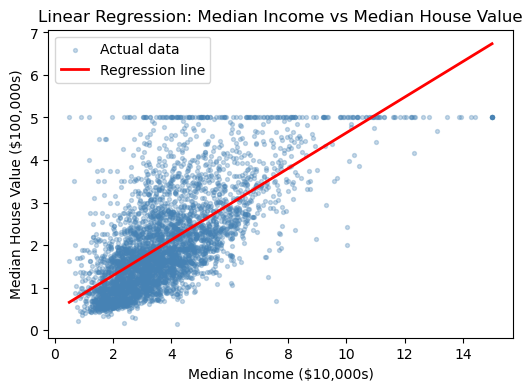

In [6]:
plt.figure(figsize=(6, 4))
plt.scatter(X_test, y_test, alpha=0.3, s=8, color='steelblue', label='Actual data')

# Sort for a clean line plot
sort_idx = X_test['MedInc'].values.argsort()
plt.plot(X_test['MedInc'].values[sort_idx], model_simple.predict(X_test)[sort_idx], color='red', linewidth=2, label='Regression line')

plt.title('Linear Regression: Median Income vs Median House Value')
plt.xlabel('Median Income ($10,000s)')
plt.ylabel('Median House Value ($100,000s)')
plt.legend()
plt.show()


## 5. Making Predictions


In [7]:
y_pred_simple = model_simple.predict(X_test)

comparison = pd.DataFrame({'Actual': y_test.values[:10], 'Predicted': y_pred_simple[:10]})
comparison

,Actual,Predicted
0,0.47700,1.149589
1,0.45800,1.506069
2,5.00001,1.903937
3,2.18600,2.850594
4,2.78000,2.006633
5,1.58700,2.421652
6,1.98200,2.576472
7,1.57500,1.992292
8,3.40000,2.458932
9,4.46600,3.846774


In [8]:
# Predicting for a brand-new, unseen value
new_income = [[8.0]]   # median income of $80,000
predicted_value = model_simple.predict(new_income)
print(f"Predicted median house value: ${predicted_value[0] * 100000:,.0f}")


Predicted median house value: $379,931


C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## 6. Understanding Residuals

A **residual** is the difference between the actual value and the predicted value for each data point: `residual = actual - predicted`. Studying residuals helps us understand where and how the model is wrong.


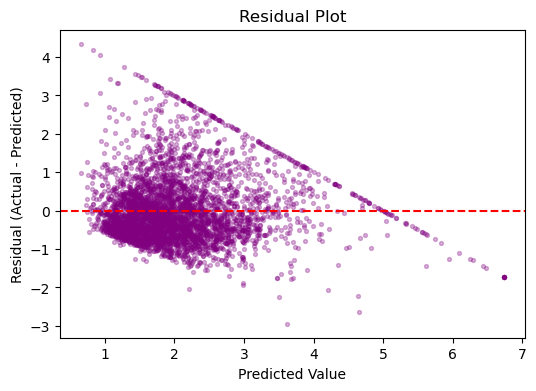

In [9]:
residuals = y_test - y_pred_simple

plt.figure(figsize=(6, 4))
plt.scatter(y_pred_simple, residuals, alpha=0.3, s=8, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Value')
plt.ylabel('Residual (Actual - Predicted)')
plt.show()


**What to look for in a residual plot:**
- Residuals scattered randomly around 0 → a reasonably good linear fit
- A clear pattern/curve in the residuals → the relationship may not be truly linear
- Residuals that fan out or narrow → the model's error is not consistent across the range (a concept called *heteroscedasticity*)

Here, we can see the residuals fan out and show some structure — a hint that a single feature and a straight line don't fully capture the relationship. This motivates using multiple features next.


## 7. Multiple Linear Regression — Using All Features

Real-world problems usually involve many relevant features. Multiple linear regression extends the same idea to use all of them together.


In [10]:
X_multi = df.drop(columns=['MedHouseValue'])
y = df['MedHouseValue']

X_train, X_test, y_train, y_test = train_test_split(X_multi, y, test_size=0.2, random_state=42)

model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

print("Training set shape:", X_train.shape)


Training set shape: (16512, 8)


In [11]:
coefficients = pd.DataFrame({
    'Feature': X_multi.columns,
    'Coefficient': model_multi.coef_
}).sort_values('Coefficient', ascending=False)

coefficients


,Feature,Coefficient
3,AveBedrms,0.783145
0,MedInc,0.448675
1,HouseAge,0.009724
4,Population,-0.000002
5,AveOccup,-0.003526
2,AveRooms,-0.123323
6,Latitude,-0.419792
7,Longitude,-0.433708


**Interpreting multiple coefficients:** each coefficient shows the effect of that feature on the prediction, *holding all other features constant*. A larger positive coefficient means that feature has a stronger positive relationship with the target (and similarly for negative coefficients), though the actual scale of each feature also affects how directly comparable these numbers are (this is one reason scaling, from Session 18, matters for some algorithms and interpretations).


In [12]:
y_pred_multi = model_multi.predict(X_test)

comparison_multi = pd.DataFrame({'Actual': y_test.values[:10], 'Predicted': y_pred_multi[:10]})
comparison_multi

,Actual,Predicted
0,0.47700,0.719123
1,0.45800,1.764017
2,5.00001,2.709659
3,2.18600,2.838926
4,2.78000,2.604657
5,1.58700,2.011754
6,1.98200,2.645500
7,1.57500,2.168755
8,3.40000,2.740746
9,4.46600,3.915615


## 8. A First Look at Evaluating Regression — R² and MSE

Full evaluation techniques are covered in Module 6, but two basic metrics are commonly used alongside every regression model:

- **MSE (Mean Squared Error)** — average of squared residuals; lower is better; same units as the target squared
- **R² (R-squared)** — proportion of variance in the target explained by the model; ranges from 0 to 1 (can be negative for a very poor model); closer to 1 is better


In [13]:
# Recompute the simple model's test predictions (same split, since random_state=42 is reused)
X_simple_train, X_simple_test, y_simple_train, y_simple_test = train_test_split(df[['MedInc']], 
                                                                                df['MedHouseValue'], 
                                                                                test_size=0.2, 
                                                                                random_state=42)
pred_simple = model_simple.predict(X_simple_test)

mse_simple = mean_squared_error(y_simple_test, pred_simple)
r2_simple = r2_score(y_simple_test, pred_simple)

mse_multi = mean_squared_error(y_test, y_pred_multi)
r2_multi = r2_score(y_test, y_pred_multi)

print("Simple Linear Regression (1 feature):  MSE =", round(mse_simple, 3), 
      " R2 =", round(r2_simple, 3))
print("Multiple Linear Regression (all features): MSE =", round(mse_multi, 3), 
      " R2 =", round(r2_multi, 3))


Simple Linear Regression (1 feature):  MSE = 0.709  R2 = 0.459
Multiple Linear Regression (all features): MSE = 0.556  R2 = 0.576


**Notice:** using all features (multiple linear regression) gives a lower MSE and a higher R² than using just one feature — the model explains more of the variation in house values when it has more relevant information to work with.


In [17]:
import statsmodels.api as sm
# Add Constant (Intercept)

X_train_sm = sm.add_constant(X_train)

# Build OLS Model

ols_model = sm.OLS(y_train, X_train_sm)

# Train Model

ols_result = ols_model.fit()

# Complete Statistical Summary

print(ols_result.summary())

                            OLS Regression Results                            
Dep. Variable:          MedHouseValue   R-squared:                       0.613
Model:                            OLS   Adj. R-squared:                  0.612
Method:                 Least Squares   F-statistic:                     3261.
Date:                Thu, 30 Jul 2026   Prob (F-statistic):               0.00
Time:                        18:36:36   Log-Likelihood:                -17998.
No. Observations:               16512   AIC:                         3.601e+04
Df Residuals:                   16503   BIC:                         3.608e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -37.0233      0.728    -50.835      0.0

In [18]:
X_test_sm = sm.add_constant(X_test)

ols_predictions = ols_result.predict(X_test_sm)

ols_predictions[:10]

20046    0.719123
3024     1.764017
15663    2.709659
20484    2.838926
9814     2.604657
13311    2.011754
7113     2.645500
7668     2.168755
18246    2.740746
5723     3.915615
dtype: float64

## 9. Assumptions and Limitations of Linear Regression

Linear regression is simple and interpretable, but it comes with assumptions worth knowing:

- **Linearity** — assumes a straight-line relationship between features and target
- **Independence** — assumes observations don't influence each other
- **Homoscedasticity** — assumes residual variance is roughly constant across all predicted values
- **Sensitivity to outliers** — extreme values can heavily pull the fitted line (a strong reason the outlier treatment from Session 14 matters before modeling)
- **Sensitivity to multicollinearity** — when features are highly correlated with each other, coefficients can become unstable and harder to interpret


## 10. Hands-on Practice Exercise 1 — Simple Linear Regression

Using `df`:

1. Build a simple linear regression model using `AveRooms` (average rooms per household) as the single feature
2. Print the coefficient and intercept
3. Plot the regression line against the test data
4. Predict the house value for a district with an average of 6 rooms per household


In [14]:
# Write your solution here



## 11. Hands-on Practice Exercise 2 — Multiple Linear Regression

1. Build a multiple linear regression model using at least 4 features of your choice (not all of them)
2. Print the coefficients and identify which feature has the strongest positive and strongest negative relationship with the target
3. Calculate and print the MSE and R² on the test set
4. Compare these results to the full-feature model built in Section 7 — is using more features always better?


In [15]:
# Write your solution here



## 12. Hands-on Practice Exercise 3 — Residual Analysis

1. Using the multiple linear regression model from Section 7, plot the residuals against the predicted values
2. Plot a histogram of the residuals — are they roughly centered around 0?
3. In a markdown cell, write 2-3 sentences describing what the residual plot suggests about how well the linear model fits this data


In [16]:
# Write your solution here



## Key Terms Glossary

| Term | Meaning |
|---|---|
| Coefficient (weight) | The learned value showing a feature's effect on the prediction |
| Intercept | The predicted value when all features are 0 |
| Cost function | A measure of how wrong the model's predictions are, which training tries to minimize |
| MSE (Mean Squared Error) | Average of squared residuals; a common regression cost/evaluation metric |
| R² (R-squared) | Proportion of variance in the target explained by the model |
| Residual | The difference between actual and predicted values for a data point |
| Simple linear regression | Regression using exactly one input feature |
| Multiple linear regression | Regression using two or more input features |
| Heteroscedasticity | Non-constant variance of residuals across the range of predictions |
| Multicollinearity | High correlation between input features, which can destabilize coefficients |


## Common Mistakes to Avoid

- Interpreting a coefficient in isolation without considering that features may be on very different scales
- Assuming a high R² automatically means a "good" model without checking residuals or considering overfitting
- Fitting a linear model to data with a clearly non-linear relationship, then being surprised by poor performance
- Not checking for outliers before fitting, since linear regression is sensitive to them (recall Session 14)
- Confusing correlation between two features with causation implied by a coefficient
- Comparing MSE values across models trained on different target scales without realizing the units differ


## Homework / Practice Assignment

1. Using `df`, build three different simple linear regression models, each using a different single feature
2. For each, record the R² and MSE on the test set, and note which single feature predicts `MedHouseValue` best on its own
3. Build one multiple linear regression model using all features, and compare its R² to your best single-feature model
4. Write 3-4 sentences summarizing what you learned about which features matter most for predicting house value
5. Come prepared with 2 questions/doubts for the next session on Logistic Regression
